# Non interacting community

In [1]:

import gifba

# load models and media:
sim = "1c"
rel_abund = [0.5, 0.5]
models, media = gifba.utils.load_simple_models(sim) # sim. 1c

# initialize community
community = gifba.gifbaObject(models, media, rel_abund=rel_abund)
# run iterations
media_flux, org_flux = community.run_gifba(iters=5, method="pfba", v=True)


Set parameter Username
Set parameter LicenseID to value 2773321
Academic license - for non-commercial use only - expires 2027-02-01
Read LP format model from file /tmp/tmpqfve0h55.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros
Read LP format model from file /tmp/tmp7i9asdsw.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros

Iteration: 0

Iteration: 1

Iteration: 2
Converged at iteration 2
Model is periodic and average of the last 1 iterations will be used for flux calculations.


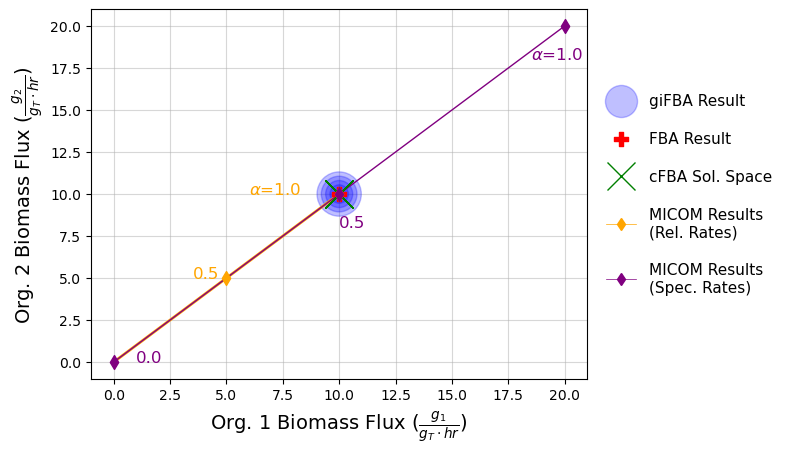

In [3]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange", "purple"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
bio1_gifba = community.org_fluxes.loc[0, :]["EX_Bio(e)"]
bio2_gifba = community.org_fluxes.loc[1, :]["EX_Bio(e)"]
plt.scatter(bio1_gifba, bio2_gifba, 
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes, 
            alpha=0.25,
            label="giFBA Result",
            zorder = 2)


# compared to cobrapy FBA
models, media = gifba.utils.load_simple_models(sim) # reload models (since giFBA changed them)
for model in models:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
for ex, flux in media.items():
    if ex in models[0].exchanges:
        models[0].exchanges.get_by_id(ex).lower_bound = flux
for ex, flux in media.items():
    if ex in models[1].exchanges:
        models[1].exchanges.get_by_id(ex).lower_bound = flux
bio1_fba = models[0].optimize().objective_value
bio2_fba = models[1].optimize().objective_value
plt.scatter(bio1_fba, bio2_fba, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)


# compared to cFBA
cfba = pd.read_csv(f"Results/cFBA/cFBA_results_sim{sim}.csv", index_col=False)
plt.plot(cfba["First_Org_Flux"], cfba["Second_Org_Max_Flux"],
            color=colors[2], 
            marker="x", 
            ms=cfba_marker_size,  
            lw=0, 
            label='cFBA Sol. Space',
            zorder=3)



def plot_micom_tradeoff_pts(micom, iterpretation, tradeoffs, rel_abund, color, ms, lw, offsets):
    # interpretation is either "specific" or "relative" to indicate which MICOM results to plot
    # offset is a tuple of (x_offset, y_offset) for each text labels
    x = micom["Org1_growth"].copy()
    y = micom["Org2_growth"].copy()
    if iterpretation == "relative":
        x /= rel_abund[0]
        y /= rel_abund[1]

    plt.plot(x, y,
            color=color, 
            lw=lw)

    for idx, alpha_tradeoff in enumerate(tradeoffs):
        
        posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
        posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
  
        if iterpretation == "relative":
                posx /= rel_abund[0]
                posy /= rel_abund[1]

        label = str(alpha_tradeoff) if alpha_tradeoff != 1.0 else r"$\alpha$=1.0"

        plt.text(posx+offsets[idx][0], posy+offsets[idx][1], 
                label,
                fontsize=12, 
                zorder=3, 
                color=color)
        
        plt.scatter(posx, posy, 
                    s=ms, 
                    c=color, 
                    marker="d", 
                    zorder=3)

        
# compared to MICOM (both interpretations)
micom = pd.read_csv("Results/micom_results.csv", index_col=0)
micom = micom.loc[sim]

plot_micom_tradeoff_pts(micom, "specific", [     0.5, 1.0], rel_abund, colors[3], micom_marker_size, 4*micom_line_width, [(-1.5, 0), (-4, 0)])
plot_micom_tradeoff_pts(micom, "relative", [0.0, 0.5, 1.0], rel_abund, colors[4], micom_marker_size, 2*micom_line_width, [(1, 0), (0, -2), (-1.5, -2)])

# create custom legend entry
micom_spec_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results (Spec. Rates)')
micom_rel_handle = plt.Line2D([0], [0], color=colors[4], lw=micom_line_width, marker="d", label='MICOM Results (Rel. Rates)')

handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_spec_handle) # add new legend entry
handles.append(micom_rel_handle) # add new legend entry
labels.append("MICOM Results\n(Rel. Rates)") # add new legend entry
labels.append("MICOM Results\n(Spec. Rates)") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='center right', bbox_to_anchor=(1.4, 0.5), ncol=1, frameon=False, labelspacing=1.5) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0, alpha=0.5)
plt.xlabel(r"Org. 1 Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"Org. 2 Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-1, 21)
plt.ylim(-1, 21)

# plt.savefig(f"Results/giFBA_Simple/gifba_sim{sim}.svg", bbox_inches='tight')
plt.savefig(f"Results/giFBA_Simple/gifba_sim{sim}.png", bbox_inches='tight')

# Simple (Unequal) Competition

In [4]:
import gifba

# load models and media:
sim = "2b"
rel_abund = [0.2, 0.8]
models, media = gifba.utils.load_simple_models(sim) 
community = gifba.gifbaObject(models, media, rel_abund=rel_abund)

# run iterations
media_flux, org_flux = community.run_gifba(iters=5, method="pfba", v=True)


Read LP format model from file /tmp/tmp0ptaayft.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros
Read LP format model from file /tmp/tmpyl5pvbh3.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros



Iteration: 0
EX_A(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 1
EX_A(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 2
EX_A(e) over-consumed by factor of 2.000000000000 (rerun count: 0)
Converged at iteration 2
Model is periodic and average of the last 1 iterations will be used for flux calculations.


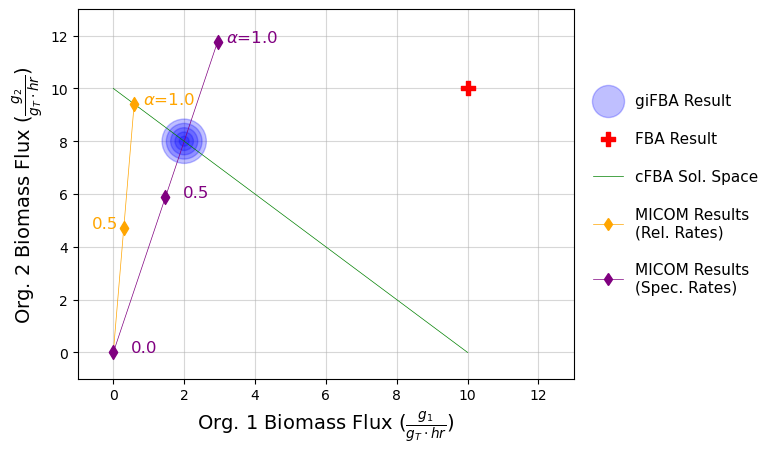

In [6]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange", "purple"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
bio1_gifba = community.org_fluxes.loc[0, :]["EX_Bio(e)"]
bio2_gifba = community.org_fluxes.loc[1, :]["EX_Bio(e)"]
plt.scatter(bio1_gifba, bio2_gifba, 
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes, 
            alpha=0.25,
            label="giFBA Result",
            zorder = 2)


# compared to cobrapy FBA
models, media = gifba.utils.load_simple_models(sim) # reload models (since giFBA changed them)
for model in models:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
for ex, flux in media.items():
    if ex in models[0].exchanges:
        models[0].exchanges.get_by_id(ex).lower_bound = flux
for ex, flux in media.items():
    if ex in models[1].exchanges:
        models[1].exchanges.get_by_id(ex).lower_bound = flux
bio1_fba = models[0].optimize().objective_value
bio2_fba = models[1].optimize().objective_value
plt.scatter(bio1_fba, bio2_fba, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)


# compared to cFBA
cfba = pd.read_csv(f"Results/cFBA/cFBA_results_sim{sim}.csv", index_col=False)
plt.plot(cfba["First_Org_Flux"], cfba["Second_Org_Max_Flux"],
            color=colors[2], 
            lw=micom_line_width, 
            label='cFBA Sol. Space',
            zorder=3)


def plot_micom_tradeoff_pts(micom, iterpretation, tradeoffs, rel_abund, color, ms, lw, offsets):
    # interpretation is either "specific" or "relative" to indicate which MICOM results to plot
    # offset is a tuple of (x_offset, y_offset) for each text labels
    x = micom["Org1_growth"].copy()
    y = micom["Org2_growth"].copy()
    if iterpretation == "relative":
        x /= rel_abund[0]
        y /= rel_abund[1]

    plt.plot(x, y,
            color=color, 
            lw=lw)

    for idx, alpha_tradeoff in enumerate(tradeoffs):
        posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values
        posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values
  
        if iterpretation == "relative":
                posx /= rel_abund[0]
                posy /= rel_abund[1]

        label = str(alpha_tradeoff) if alpha_tradeoff != 1.0 else r"$\alpha$=1.0"

        plt.text(posx+offsets[idx][0], posy+offsets[idx][1], 
                label,
                fontsize=12, 
                zorder=3, 
                color=color)
        
        plt.scatter(posx, posy, 
                    s=ms, 
                    c=color, 
                    marker="d", 
                    zorder=3)

        
# compared to MICOM (both interpretations)
micom = pd.read_csv("Results/micom_results.csv", index_col=0)
micom = micom.loc[sim]

plot_micom_tradeoff_pts(micom, "specific", [     0.5, 1.0], rel_abund, colors[3], micom_marker_size, micom_line_width, [(-0.9, 0), (0.25, 0)])
plot_micom_tradeoff_pts(micom, "relative", [0.0, 0.5, 1.0], rel_abund, colors[4], micom_marker_size, micom_line_width, [(0.5, 0), (0.5, 0), (0.25, 0)])

# create custom legend entry
micom_spec_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results (Spec. Rates)')
micom_rel_handle = plt.Line2D([0], [0], color=colors[4], lw=micom_line_width, marker="d", label='MICOM Results (Rel. Rates)')

handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_spec_handle) # add new legend entry
handles.append(micom_rel_handle) # add new legend entry
labels.append("MICOM Results\n(Rel. Rates)") # add new legend entry
labels.append("MICOM Results\n(Spec. Rates)") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='center right', bbox_to_anchor=(1.4, 0.5), ncol=1, frameon=False, labelspacing=1.5) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0, alpha=0.5)
plt.xlabel(r"Org. 1 Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"Org. 2 Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-1, 13)
plt.ylim(-1, 13)

# plt.savefig(f"Results/giFBA_Simple/gifba_sim{sim}.svg", bbox_inches='tight')
plt.savefig(f"Results/giFBA_Simple/gifba_sim{sim}.png", bbox_inches='tight')

# Cross-feeding

In [7]:
import gifba

# load models and media:
sim = "3a"
rel_abund = [0.5, 0.5]
models, media = gifba.utils.load_simple_models(sim) # sim. 3a

# initialize community
community = gifba.gifbaObject(models, media, rel_abund=rel_abund)
# run iterations
media_flux, org_flux = community.run_gifba(iters=5, method="pfba",   v=True)



Read LP format model from file /tmp/tmp8mfgq3lt.lp
Reading time = 0.00 seconds
: 6 rows, 16 columns, 26 nonzeros


Read LP format model from file /tmp/tmp8ffu6hft.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros

Iteration: 0

Iteration: 1

Iteration: 2

Iteration: 3
Converged at iteration 3
Model is periodic and average of the last 1 iterations will be used for flux calculations.


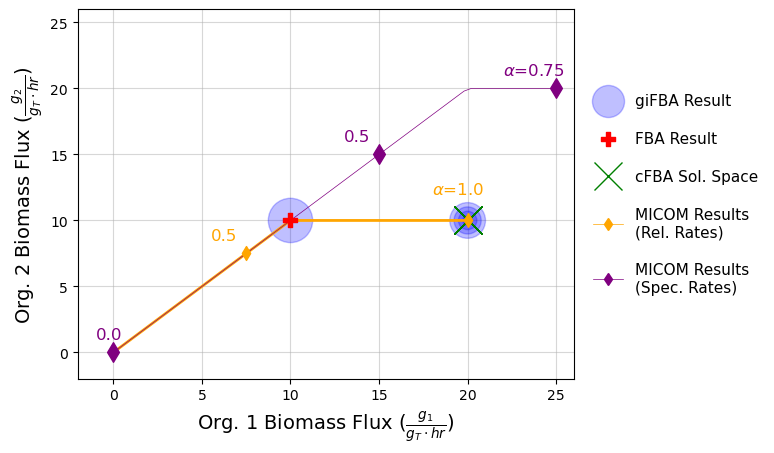

In [8]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange", "purple"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
bio1_gifba = community.org_fluxes.loc[0, :]["EX_Bio(e)"]
bio2_gifba = community.org_fluxes.loc[1, :]["EX_Bio(e)"]
plt.scatter(bio1_gifba, bio2_gifba, 
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes, 
            alpha=0.25,
            label="giFBA Result",
            zorder = 2)


# compared to cobrapy FBA
models, media = gifba.utils.load_simple_models(sim) # reload models (since giFBA changed them)
for model in models:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
for ex, flux in media.items():
    if ex in models[0].exchanges:
        models[0].exchanges.get_by_id(ex).lower_bound = flux
for ex, flux in media.items():
    if ex in models[1].exchanges:
        models[1].exchanges.get_by_id(ex).lower_bound = flux
bio1_fba = models[0].optimize().objective_value
bio2_fba = models[1].optimize().objective_value
plt.scatter(bio1_fba, bio2_fba, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)


# compared to cFBA
cfba = pd.read_csv(f"Results/cFBA/cFBA_results_sim{sim}.csv", index_col=False)
plt.plot(cfba["First_Org_Flux"], cfba["Second_Org_Max_Flux"],
            color=colors[2], 
            marker="x", 
            ms=cfba_marker_size,  
            lw=0, 
            label='cFBA Sol. Space',
            zorder=3)


def plot_micom_tradeoff_pts(micom, iterpretation, tradeoffs, rel_abund, color, ms, lw, offsets):
    # interpretation is either "specific" or "relative" to indicate which MICOM results to plot
    # offset is a tuple of (x_offset, y_offset) for each text labels
    x = micom["Org1_growth"].copy()
    y = micom["Org2_growth"].copy()
    if iterpretation == "relative":
        x /= rel_abund[0]
        y /= rel_abund[1]

    plt.plot(x, y,
            color=color, 
            lw=lw)

    for idx, alpha_tradeoff in enumerate(tradeoffs):
        posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values
        posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values
  
        if iterpretation == "relative":
                posx /= rel_abund[0]
                posy /= rel_abund[1]

        label = str(alpha_tradeoff) if alpha_tradeoff != 1.0 else r"$\alpha$=1.0"
        if alpha_tradeoff == 0.75 and iterpretation == "relative":
            label = r"$\alpha$=0.75"

        plt.text(posx+offsets[idx][0], posy+offsets[idx][1], 
                label,
                fontsize=12, 
                zorder=3, 
                color=color)
        
        plt.scatter(posx, posy, 
                    s=ms, 
                    c=color, 
                    marker="d", 
                    zorder=3)

        
# compared to MICOM (both interpretations)
micom = pd.read_csv("Results/micom_results.csv", index_col=0)
micom = micom.loc[sim]

plot_micom_tradeoff_pts(micom, "specific", [     0.5, 1.0], rel_abund, colors[3], micom_marker_size, 4 * micom_line_width, [(-2, 1), (-2, 2)])
plot_micom_tradeoff_pts(micom[micom["tradeoff"] <= 0.75], "relative", [0.0, 0.5, 0.75], rel_abund, colors[4], 2* micom_marker_size, micom_line_width, [(-1, 1), (-2, 1), (-3, 1)])

# create custom legend entry
micom_spec_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results (Spec. Rates)')
micom_rel_handle = plt.Line2D([0], [0], color=colors[4], lw=micom_line_width, marker="d", label='MICOM Results (Rel. Rates)')

handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_spec_handle) # add new legend entry
handles.append(micom_rel_handle) # add new legend entry
labels.append("MICOM Results\n(Rel. Rates)") # add new legend entry
labels.append("MICOM Results\n(Spec. Rates)") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='center right', bbox_to_anchor=(1.4, 0.5), ncol=1, frameon=False, labelspacing=1.5) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0, alpha=0.5)
plt.xlabel(r"Org. 1 Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"Org. 2 Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-2, 26)
plt.ylim(-2, 26)

# plt.savefig(f"Results/giFBA_Simple/gifba_sim{sim}.svg", bbox_inches='tight')
plt.savefig(f"Results/giFBA_Simple/gifba_sim{sim}.png", bbox_inches='tight')

# Growth-Coupled Simulation


In [16]:
import gifba

# load models and media:
sim = "5b"
rel_abund = [0.2, 0.8]
models, media = gifba.utils.load_simple_models(sim) 
community = gifba.gifbaObject(models, media, rel_abund=rel_abund)
# run iterations
media_flux, org_flux = community.run_gifba(iters=5, method="pfba",   v=True)

Read LP format model from file /tmp/tmpuhh9pa16.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros
Read LP format model from file /tmp/tmpeemtgpf6.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros

Iteration: 0

Iteration: 1
EX_A(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 2
EX_A(e) over-consumed by factor of 1.200000000000 (rerun count: 0)

Iteration: 3
EX_A(e) over-consumed by factor of 1.800000000000 (rerun count: 0)

Iteration: 4
EX_A(e) over-consumed by factor of 1.200000000000 (rerun count: 0)
Converged at iteration 4
Model is periodic and average of the last 2 iterations will be used for flux calculations.


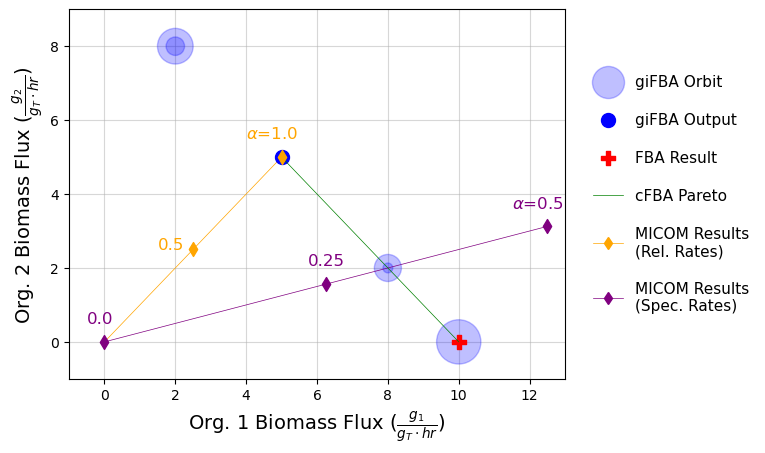

In [22]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange", "purple"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
bio1_gifba = community.org_fluxes.loc[0, :]["EX_Bio(e)"]
bio2_gifba = community.org_fluxes.loc[1, :]["EX_Bio(e)"]
plt.scatter(bio1_gifba, bio2_gifba, 
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes, 
            alpha=0.25,
            label="giFBA Orbit",
            zorder = 2)
plt.scatter(org_flux.loc[0]["EX_Bio(e)"], org_flux.loc[1]["EX_Bio(e)"],
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes[-1]*2, 
            label="giFBA Output",
            zorder = 3)


# compared to cobrapy FBA
models, media = gifba.utils.load_simple_models(sim) # reload models (since giFBA changed them)
for model in models:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
for ex, flux in media.items():
    if ex in models[0].exchanges:
        models[0].exchanges.get_by_id(ex).lower_bound = flux
for ex, flux in media.items():
    if ex in models[1].exchanges:
        models[1].exchanges.get_by_id(ex).lower_bound = flux
bio1_fba = models[0].optimize().objective_value
bio2_fba = models[1].optimize().objective_value
plt.scatter(bio1_fba, bio2_fba, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)


# compared to cFBA
cfba = pd.read_csv(f"Results/cFBA/cFBA_results_sim{sim}.csv", index_col=False)
plt.plot(cfba["First_Org_Flux"], cfba["Second_Org_Max_Flux"],
            color=colors[2], 
            lw=micom_line_width, 
            label='cFBA Pareto',
            zorder=3)


def plot_micom_tradeoff_pts(micom, iterpretation, tradeoffs, rel_abund, color, ms, lw, offsets):
    # interpretation is either "specific" or "relative" to indicate which MICOM results to plot
    # offset is a tuple of (x_offset, y_offset) for each text labels
    x = micom["Org1_growth"].copy()
    y = micom["Org2_growth"].copy()
    if iterpretation == "relative":
        x /= rel_abund[0]
        y /= rel_abund[1]

    plt.plot(x, y,
            color=color, 
            lw=lw)

    for idx, alpha_tradeoff in enumerate(tradeoffs):
        
        posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values
        posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values
  
        if iterpretation == "relative":
                posx /= rel_abund[0]
                posy /= rel_abund[1]

        label = str(alpha_tradeoff) if alpha_tradeoff != 1.0 else r"$\alpha$=1.0"
        if alpha_tradeoff == 0.5 and iterpretation == "relative":
            label = r"$\alpha$=0.5"

        plt.text(posx+offsets[idx][0], posy+offsets[idx][1], 
                label,
                fontsize=12, 
                zorder=3, 
                color=color)
        
        plt.scatter(posx, posy, 
                    s=ms, 
                    c=color, 
                    marker="d", 
                    zorder=3)

# compared to MICOM (both interpretations)
micom = pd.read_csv("Results/micom_results.csv", index_col=0)
micom = micom.loc[sim]

plot_micom_tradeoff_pts(micom                          , "specific", [      0.5, 1.0], rel_abund, colors[3], micom_marker_size, micom_line_width, [(-1, 0), (-1, 0.5)])
plot_micom_tradeoff_pts(micom[micom["tradeoff"] <= 0.5], "relative", [0.0, 0.25, 0.5], rel_abund, colors[4], micom_marker_size, micom_line_width, [(-0.5, 0.5), (-0.5, 0.5), (-1, 0.5)])

# create custom legend entry
micom_spec_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results (Spec. Rates)')
micom_rel_handle = plt.Line2D([0], [0], color=colors[4], lw=micom_line_width, marker="d", label='MICOM Results (Rel. Rates)')

handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_spec_handle) # add new legend entry
handles.append(micom_rel_handle) # add new legend entry
labels.append("MICOM Results\n(Rel. Rates)") # add new legend entry
labels.append("MICOM Results\n(Spec. Rates)") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='center right', bbox_to_anchor=(1.4, 0.5), ncol=1, frameon=False, labelspacing=1.5) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0, alpha=0.5)
plt.xlabel(r"Org. 1 Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"Org. 2 Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-1, 13)
plt.ylim(-1, 9)
# plt.tight_layout()

plt.savefig(f"Results/giFBA_Simple/gifba_sim{sim}.svg", bbox_inches='tight')

# B infantis & A hallii (Growth coupling)

In [9]:
import cobra as cb
import gifba
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BI = cb.io.load_matlab_model('AGORA2_Models/Bifidobacterium_longum_infantis_ATCC_15697.mat')
AH = cb.io.load_matlab_model('AGORA2_Models/Eubacterium_hallii_DSM_3353.mat')

models = [BI, AH]

# AGORA Format
media = {
	'EX_o2(e)': 0, #aerobic/anaerobic
	'EX_h2o(e)': -1000,
	'EX_pi(e)': -1000,
	'EX_fe2(e)': -1000,
	'EX_fe3(e)': -1000,
	'EX_zn2(e)': -1000,
	'EX_so4(e)': -1000,
	'EX_cu2(e)': -1000,
	'EX_k(e)': -1000,
	'EX_mg2(e)': -1000,
	'EX_mn2(e)': -1000,
	'EX_cd2(e)': -1000,
	'EX_cl(e)': -1000,
	'EX_ca2(e)': -1000,
	'EX_cobalt2(e)': -1000,
	'EX_glc_D(e)': -10,
	'EX_nh4(e)': -20,

	'EX_ribflv(e)': -1000,
	'EX_pnto_R(e)': -1000,
	'EX_nac(e)': -1000,
	'EX_his_L(e)': -1000,
	'EX_asn_L(e)': -1000,
	'EX_glycys(e)': -1000,

	'EX_lys_L(e)': -1000,
	'EX_ala_L(e)': -1000,
	'EX_met_L(e)': -1000,
	'EX_leu_L(e)': -1000,
	'EX_hxan(e)': -1000,    
    'EX_glyglu(e)': -1000
	# 'EX_ser_L(e)': -1 #-1
}

# initialize community
rel_abund = [0.5, 0.5]
community = gifba.gifbaObject(models, media, rel_abund=rel_abund)

# run iterations
media_flux, org_flux = community.run_gifba(iters=5, method="pfba", threshold=0.0000001, v=True)

No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e


Read LP format model from file /tmp/tmpms4h0uzs.lp
Reading time = 0.00 seconds
: 932 rows, 2064 columns, 8440 nonzeros
Read LP format model from file /tmp/tmpf4di9hdn.lp
Reading time = 0.00 seconds
: 980 rows, 2102 columns, 8980 nonzeros

Iteration: 0
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 1
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 2
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 3
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 4
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)
Model did not converge or show periodicity within the iteration limit, results may be unreliable.
4 iterations (90.0%) will be used for flux calculations, but consider increasing the number of iterations or checking model setup.
Model is periodic and average of the last 4 iterations will be used for flux calculations.


BI FBA optimal: 0.13353637458967868
AH FBA optimal: 0.4147595691023793


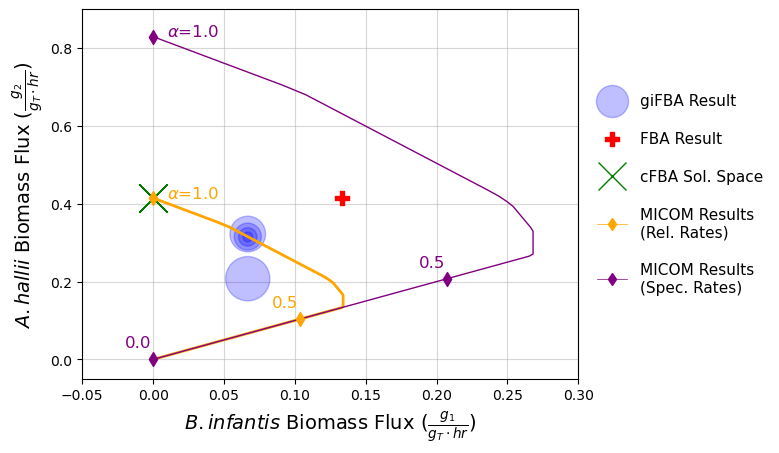

In [10]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange", "purple"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
BI_gifba = community.org_fluxes.loc[0, :]["EX_biomass(e)"]
AH_gifba = community.org_fluxes.loc[1, :]["EX_biomass(e)"]
plt.scatter(BI_gifba, AH_gifba, 
			color=colors[0],
			marker="o", 
			s=gifba_marker_sizes, 
			alpha=0.25,
			label="giFBA Result",
			zorder = 2)

# compared to cobrapy FBA
for model in models:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
        model.exchanges.get_by_id(ex.id).upper_bound = 1000
for ex, flux in media.items():
    if ex in BI.exchanges:
        BI.exchanges.get_by_id(ex).lower_bound = flux
BI_optimal = BI.optimize().objective_value

for ex, flux in media.items():
    if ex in AH.exchanges:
        AH.exchanges.get_by_id(ex).lower_bound = flux
AH_optimal = AH.optimize().objective_value

print("BI FBA optimal:", BI_optimal)
print("AH FBA optimal:", AH_optimal)

plt.scatter(BI_optimal, AH_optimal, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)

# compared to cFBA
cfba = pd.read_csv(f"Results/cFBA/cFBA_results_BI_AH.csv", index_col=False)
plt.plot(cfba["First_Org_Flux"], cfba["Second_Org_Max_Flux"],
            color=colors[2], 
            marker="x", 
            ms=cfba_marker_size,  
            lw=0, 
            label='cFBA Sol. Space',
            zorder=3)

# compared to MICOM
sim = "BI_AH"
def plot_micom_tradeoff_pts(micom, iterpretation, tradeoffs, rel_abund, color, ms, lw, offsets):
    # interpretation is either "specific" or "relative" to indicate which MICOM results to plot
    # offset is a tuple of (x_offset, y_offset) for each text labels
    x = micom["Org1_growth"].copy()
    y = micom["Org2_growth"].copy()
    if iterpretation == "relative":
        x /= rel_abund[0]
        y /= rel_abund[1]

    plt.plot(x, y,
            color=color, 
            lw=lw)

    for idx, alpha_tradeoff in enumerate(tradeoffs):
        
        posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values
        posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values
  
        if iterpretation == "relative":
                posx /= rel_abund[0]
                posy /= rel_abund[1]

        label = str(alpha_tradeoff) if alpha_tradeoff != 1.0 else r"$\alpha$=1.0"

        plt.text(posx+offsets[idx][0], posy+offsets[idx][1], 
                label,
                fontsize=12, 
                zorder=3, 
                color=color)
        
        plt.scatter(posx, posy, 
                    s=ms, 
                    c=color, 
                    marker="d", 
                    zorder=3)

# compared to MICOM (both interpretations)
micom = pd.read_csv("Results/micom_results_real.csv", index_col=0)
micom = micom.loc[sim]

plot_micom_tradeoff_pts(micom, "specific", [     0.5, 1.0], rel_abund, colors[3], micom_marker_size, 4*micom_line_width, [(-0.02, 0.03), (0.01, 0)])
plot_micom_tradeoff_pts(micom, "relative", [0.0, 0.5, 1.0], rel_abund, colors[4], micom_marker_size, 2*micom_line_width, [(-0.02, 0.03), (-0.02, 0.03), (0.01, 0)])

# create custom legend entry
micom_spec_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results (Spec. Rates)')
micom_rel_handle = plt.Line2D([0], [0], color=colors[4], lw=micom_line_width, marker="d", label='MICOM Results (Rel. Rates)')

handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_spec_handle) # add new legend entry
handles.append(micom_rel_handle) # add new legend entry
labels.append("MICOM Results\n(Rel. Rates)") # add new legend entry
labels.append("MICOM Results\n(Spec. Rates)") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='center right', bbox_to_anchor=(1.4, 0.5), ncol=1, frameon=False, labelspacing=1.5) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0, alpha=0.5)
plt.xlabel(r"$\it{B. infantis}$ Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"$\it{A. hallii}$ Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-0.05, 0.3)
plt.ylim(-0.05, 0.9)

# plt.savefig(f"Results/giFBA_AGORA/gifba_BIAH.svg", bbox_inches='tight')
plt.savefig(f"Results/giFBA_AGORA/gifba_BIAH.png", bbox_inches='tight')

In [16]:
# generate community summary
summary = community.summarize()
edge, node = summary.to_cytoscape()
print(edge["Value"].describe())
print(edge[np.abs(edge["Value"]) > 0.02]["Value"].describe())
edge_shown = edge[np.abs(edge["Value"]) > 0.05]
for row in edge_shown[["Source", "Target"]].itertuples():
    print(f"{row.Source} -> {row.Target}")
    connected_ids = set(edge_shown["Source"]).union(edge_shown["Target"])
    node_shown = node[node["ID"].isin(connected_ids)].copy()

edge_shown.to_csv("Results/giFBA_AGORA/BI_AH_edges.csv")
node_shown.to_csv("Results/giFBA_AGORA/BI_AH_nodes.csv")
# summary

count    65.000000
mean      1.549713
std       3.688984
min       0.000521
25%       0.002475
50%       0.029349
75%       0.316868
max      17.173323
Name: Value, dtype: float64
count    35.000000
mean      2.875601
std       4.657810
min       0.028591
25%       0.086592
50%       0.228013
75%       5.000000
max      17.173323
Name: Value, dtype: float64
Eubacterium hallii DSM 3353 -> leu_L[e]
Eubacterium hallii DSM 3353 -> ala_L[e]
Eubacterium hallii DSM 3353 -> lys_L[e]
Bifidobacterium longum infantis ATCC 15697 -> h[e]
Eubacterium hallii DSM 3353 -> h[e]
Bifidobacterium longum infantis ATCC 15697 -> 4abut[e]
Eubacterium hallii DSM 3353 -> asn_L[e]
Bifidobacterium longum infantis ATCC 15697 -> glc_D[e]
Eubacterium hallii DSM 3353 -> glc_D[e]
Bifidobacterium longum infantis ATCC 15697 -> lac_L[e]
Eubacterium hallii DSM 3353 -> lac_L[e]
Bifidobacterium longum infantis ATCC 15697 -> co2[e]
Eubacterium hallii DSM 3353 -> co2[e]
Eubacterium hallii DSM 3353 -> hxan[e]
Eubacterium hallii

In [4]:
# create node table for rxns made of fluxes with names changed
node_table = pd.DataFrame(columns=["sbml id", "flux", "type"])

print(summary.shape)


AttributeError: 'CommunitySummary' object has no attribute 'shape'